In [1]:
from IPython import get_ipython
get_ipython().run_line_magic('reset', '-sf')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
#%matplotlib notebook
# Turn off interactive mode
plt.ioff()
plt.rcParams['interactive'] = False

#sns.set()
sns.set_style("ticks")
#sns.set_style({"xtick.direction": "in","ytick.direction": "in"})
#sns.set(rc={"xtick.bottom" : True, "ytick.left" : True})

#plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=30)  # fontsize of the axes title
plt.rc('axes', labelsize=30)  # fontsize of the x and y labels
plt.rc('xtick', labelsize=30)  # fontsize of the tick labels
plt.rc('ytick', labelsize=30)  # fontsize of the tick labels
plt.rc('legend', fontsize=30)  # legend fontsize
#plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
plt.rc('font', **{'family': 'serif', 'serif': ['Times New Roman']})
plt.rc('text', usetex=True)

plt.rc('xtick', direction='in') #xticks are plotted inside the figure
plt.rc('ytick', direction='in') #yticks are plotted inside the figure
plt.rcParams['xtick.major.pad'] = 10 #distance between ticks and numbers
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True

# set tick width and border width
plt.rcParams['xtick.major.size'] = 7
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['xtick.minor.size'] = 5
plt.rcParams['xtick.minor.width'] = 1

plt.rcParams['ytick.major.size'] = 7
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['ytick.minor.size'] = 5
plt.rcParams['ytick.minor.width'] = 1

plt.rcParams['axes.linewidth'] = 2



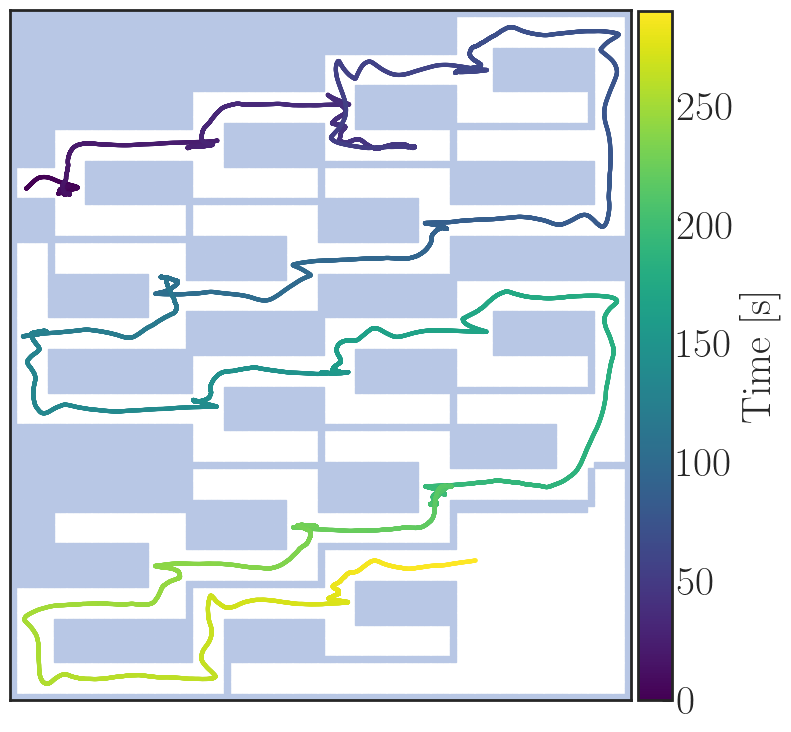

In [4]:
import matplotlib.pyplot as plt
import sys
import os
import numpy as np
import pandas as pd

sys.path.append(os.path.join(os.getcwd(), 'strategy_comparison'))
from maze_functions import maze_from_file

# Data directory
data = '/home/mukhopadhyay/Projects/maze/GNU_parallel_runs/optimal_beta_Ran_droplet/data/'

# Load the maze
maze = maze_from_file('strategy_comparison/different_mazes/Ran_maze_size_prop_to_droplet.tsv')
wall = np.transpose(np.where(maze == 0))

# Load the particle trajectory using pandas
df = pd.read_csv(data + '/full_traj_652.txt', sep=' ')

# Fix the scales for conc, time and position (adjust the units in plot titles accordingly)
t_unit = 10 # s
r_unit = 0.4 # cm
beta_scale = 1e+04

# Extract columns by name
x_traj = df['X']
y_traj = df['Y']
qty_to_plot = df['Time'] * t_unit

# Plot background
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(maze.T, cmap='gray', origin='lower', alpha=0.0)

# Plot wall points
ax.plot(wall[:, 0], wall[:, 1], 's', markersize=5, color='#B8C7E5')

# Plot particle trajectories
traj = ax.scatter(x_traj, y_traj, s=4.0, c=qty_to_plot, cmap='viridis', alpha=1.0)
cbar_traj = plt.colorbar(traj, label="Time [s]", fraction=0.052, pad=0.01)

plt.xticks([])
plt.yticks([])
fig.tight_layout()
plt.show()

#fig.savefig('/home/mukhopadhyay/Projects/maze/paper_figures/individual_figures/' + 'Ran_droplet_trajectory_time.png', dpi=300, bbox_inches='tight')

In [5]:
np.max(qty_to_plot)

289.73

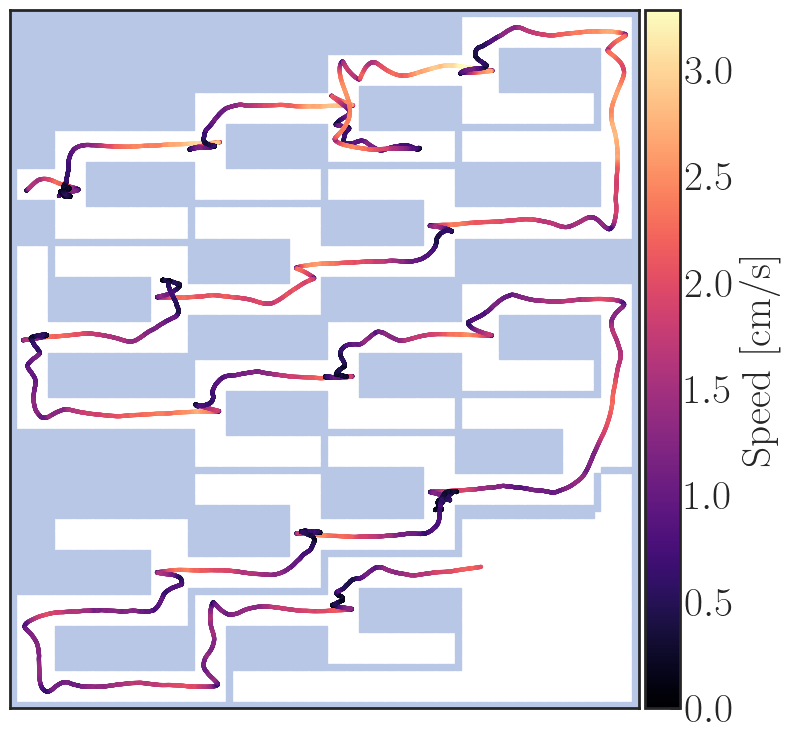

In [2]:
import matplotlib.pyplot as plt
import sys
import os
import numpy as np
import pandas as pd

sys.path.append(os.path.join(os.getcwd(), 'strategy_comparison'))
from maze_functions import maze_from_file

# Data directory
data = '/home/mukhopadhyay/Projects/maze/GNU_parallel_runs/optimal_beta_Ran_droplet/data/'

# Load the maze
maze = maze_from_file('strategy_comparison/different_mazes/Ran_maze_size_prop_to_droplet.tsv')
wall = np.transpose(np.where(maze == 0))

# Load the particle trajectory using pandas
df = pd.read_csv(data + '/full_traj_652.txt', sep=' ')

# Fix the scales for conc, time and position (adjust the units in plot titles accordingly)
t_unit = 10 # s
r_unit = 0.4 # cm
v_unit = r_unit/t_unit # cm/s
beta_scale = 1e+04

# Extract columns by name
x_traj = df['X']
y_traj = df['Y']
qty_to_plot = np.sqrt(df['VX']*df['VX'] + df['VY']*df['VY']) * v_unit

# Plot background
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(maze.T, cmap='gray', origin='lower', alpha=0.0)

# Plot wall points
ax.plot(wall[:, 0], wall[:, 1], 's', markersize=5, color='#B8C7E5')

# Plot particle trajectories
traj = ax.scatter(x_traj, y_traj, s=4.0, c=qty_to_plot, cmap='magma', alpha=1.0)
cbar_traj = plt.colorbar(traj, label="Speed [cm/s]", fraction=0.052, pad=0.01)

plt.xticks([])
plt.yticks([])
fig.tight_layout()
plt.show()

#fig.savefig('/home/mukhopadhyay/Projects/maze/paper_figures/individual_figures/' + 'Ran_droplet_trajectory_speed.png', dpi=300, bbox_inches='tight')

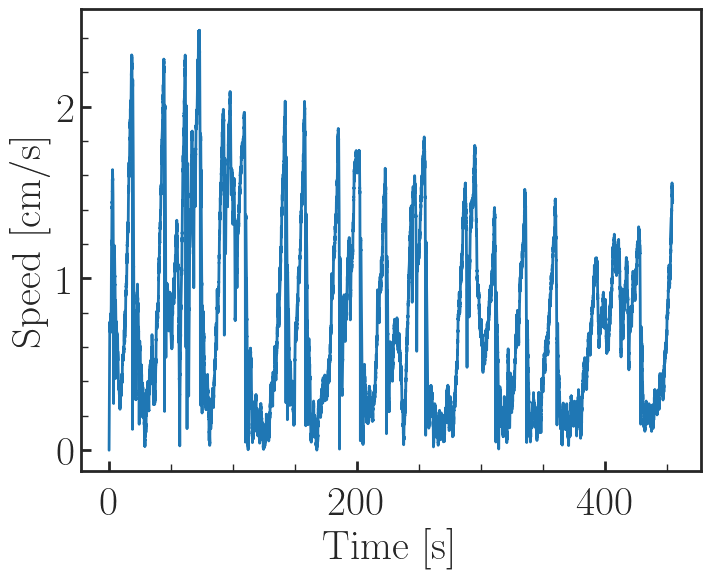

In [76]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Data directory
data = 'trajectories_our_droplet/data/'  # for linux

# Load the particle trajectory using pandas
df = pd.read_csv(data + '/full_traj_1.txt', sep=' ')

# Calculate the speed
df['Speed'] = np.sqrt(df['VX']**2 + df['VY']**2)

# Extract time and speed
time = df['Time']
speed = df['Speed']

# Plot velocity magnitude vs time
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(time*7, speed*0.06, linewidth=2)

# Plot settings
ax.set_xlabel('Time [s]')
ax.set_ylabel('Speed [cm/s]')

plt.show()


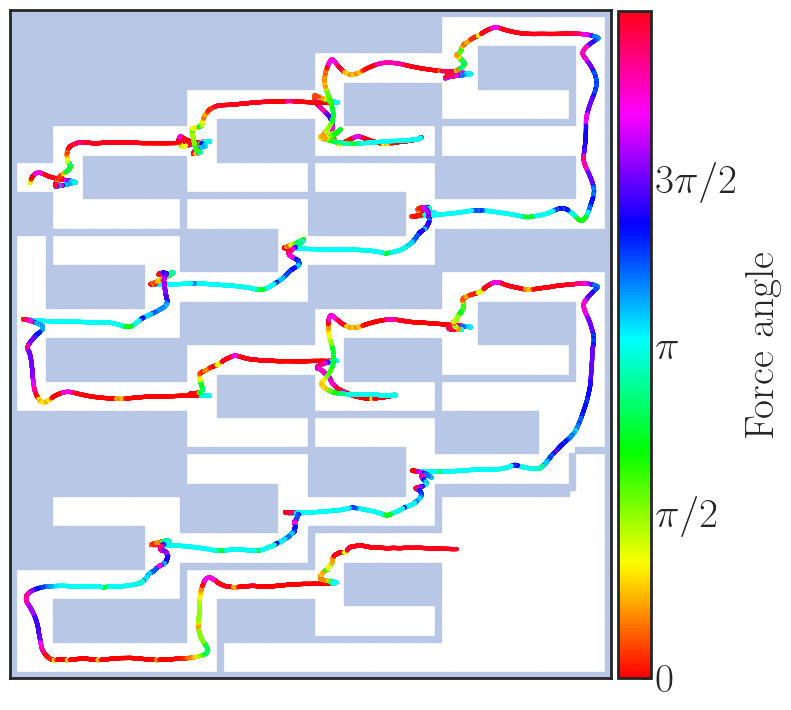

In [89]:
import matplotlib.pyplot as plt
import sys
import os
import numpy as np
import pandas as pd

sys.path.append(os.path.join(os.getcwd(), 'beta_vs_exit_time_our_droplet'))
from maze_functions import maze_from_file

# Data directory
data = 'trajectories_our_droplet/data/'  # for linux

# Load the maze
maze = maze_from_file('trajectories_our_droplet/different_mazes/Ran_maze_size_prop_to_droplet.tsv')
wall = np.transpose(np.where(maze == 0))

# Load the particle trajectory using pandas
df = pd.read_csv(data + '/full_traj_1.txt', sep=' ')

# Extract columns by name
x_traj = df['X']
y_traj = df['Y']
qty_to_plot = np.arctan2(df['f_chemy'], df['f_chemx'])%(2.0*np.pi)

# Plot background
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(maze.T, cmap='gray', origin='lower', alpha=0.0)

# Plot wall points
ax.plot(wall[:, 0], wall[:, 1], 's', markersize=5, color='#B8C7E5')

# Plot particle trajectories
traj = ax.scatter(x_traj, y_traj, s=4.0, c=qty_to_plot, cmap='hsv', alpha=1.0)
cbar_traj = plt.colorbar(traj, label="Force angle", fraction=0.052, pad=0.01, ticks=[0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
cbar_traj.set_ticklabels(['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])

plt.xticks([])
plt.yticks([])
fig.tight_layout()
plt.show()


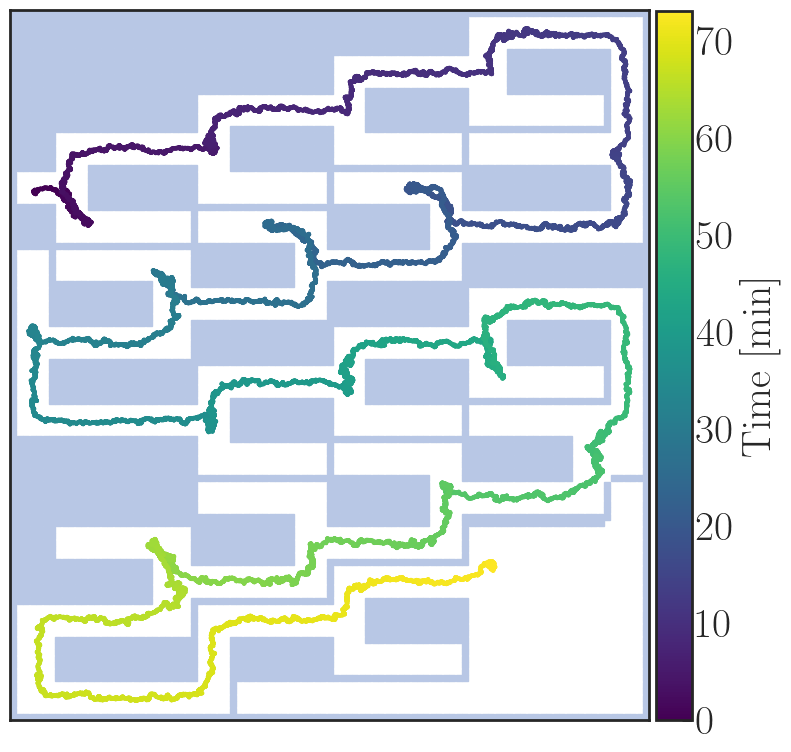

In [ ]:
# Trail trajectory

import matplotlib.pyplot as plt
import sys
import os
import numpy as np
import pandas as pd

sys.path.append(os.path.join(os.getcwd(), 'strategy_comparison'))
from maze_functions import maze_from_file

# Data directory
data = '/home/mukhopadhyay/Projects/maze/GNU_parallel_runs/trajectory_video/data/'

# Load the maze
maze = maze_from_file('strategy_comparison/different_mazes/Ran_maze_size_prop_to_droplet.tsv')
wall = np.transpose(np.where(maze == 0))

# Load the particle trajectory using pandas
df = pd.read_csv(data + '/full_traj_1.txt', sep=' ')

# Fix the scales for conc, time and position (adjust the units in plot titles accordingly)
t_unit = 60/60 # min
r_unit = 1e-04 # cm
beta_scale = 1e+04

# Extract columns by name
x_traj = df['X']
y_traj = df['Y']
qty_to_plot = df['Time'] * t_unit

# Plot background
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(maze.T, cmap='gray', origin='lower', alpha=0.0)

# Plot wall points
ax.plot(wall[:, 0], wall[:, 1], 's', markersize=5, color='#B8C7E5')

# Plot particle trajectories
traj = ax.scatter(x_traj, y_traj, s=4.0, c=qty_to_plot, cmap='viridis', alpha=1.0)
cbar_traj = plt.colorbar(traj, label="Time [min]", fraction=0.052, pad=0.01)

plt.xticks([])
plt.yticks([])
fig.tight_layout()
plt.show()